<a href="https://colab.research.google.com/github/sravand2001/guild-mle-projects/blob/main/Student_MLE_MiniProject_Trees_and_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Load the Breast Cancer Wisconsin dataset
dataset = load_breast_cancer()

In [ ]:
# Split the dataset into training and testing sets
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

df['target'] = dataset.target
df.head()

x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Display first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Create a Decision Tree model
classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=40)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=40)

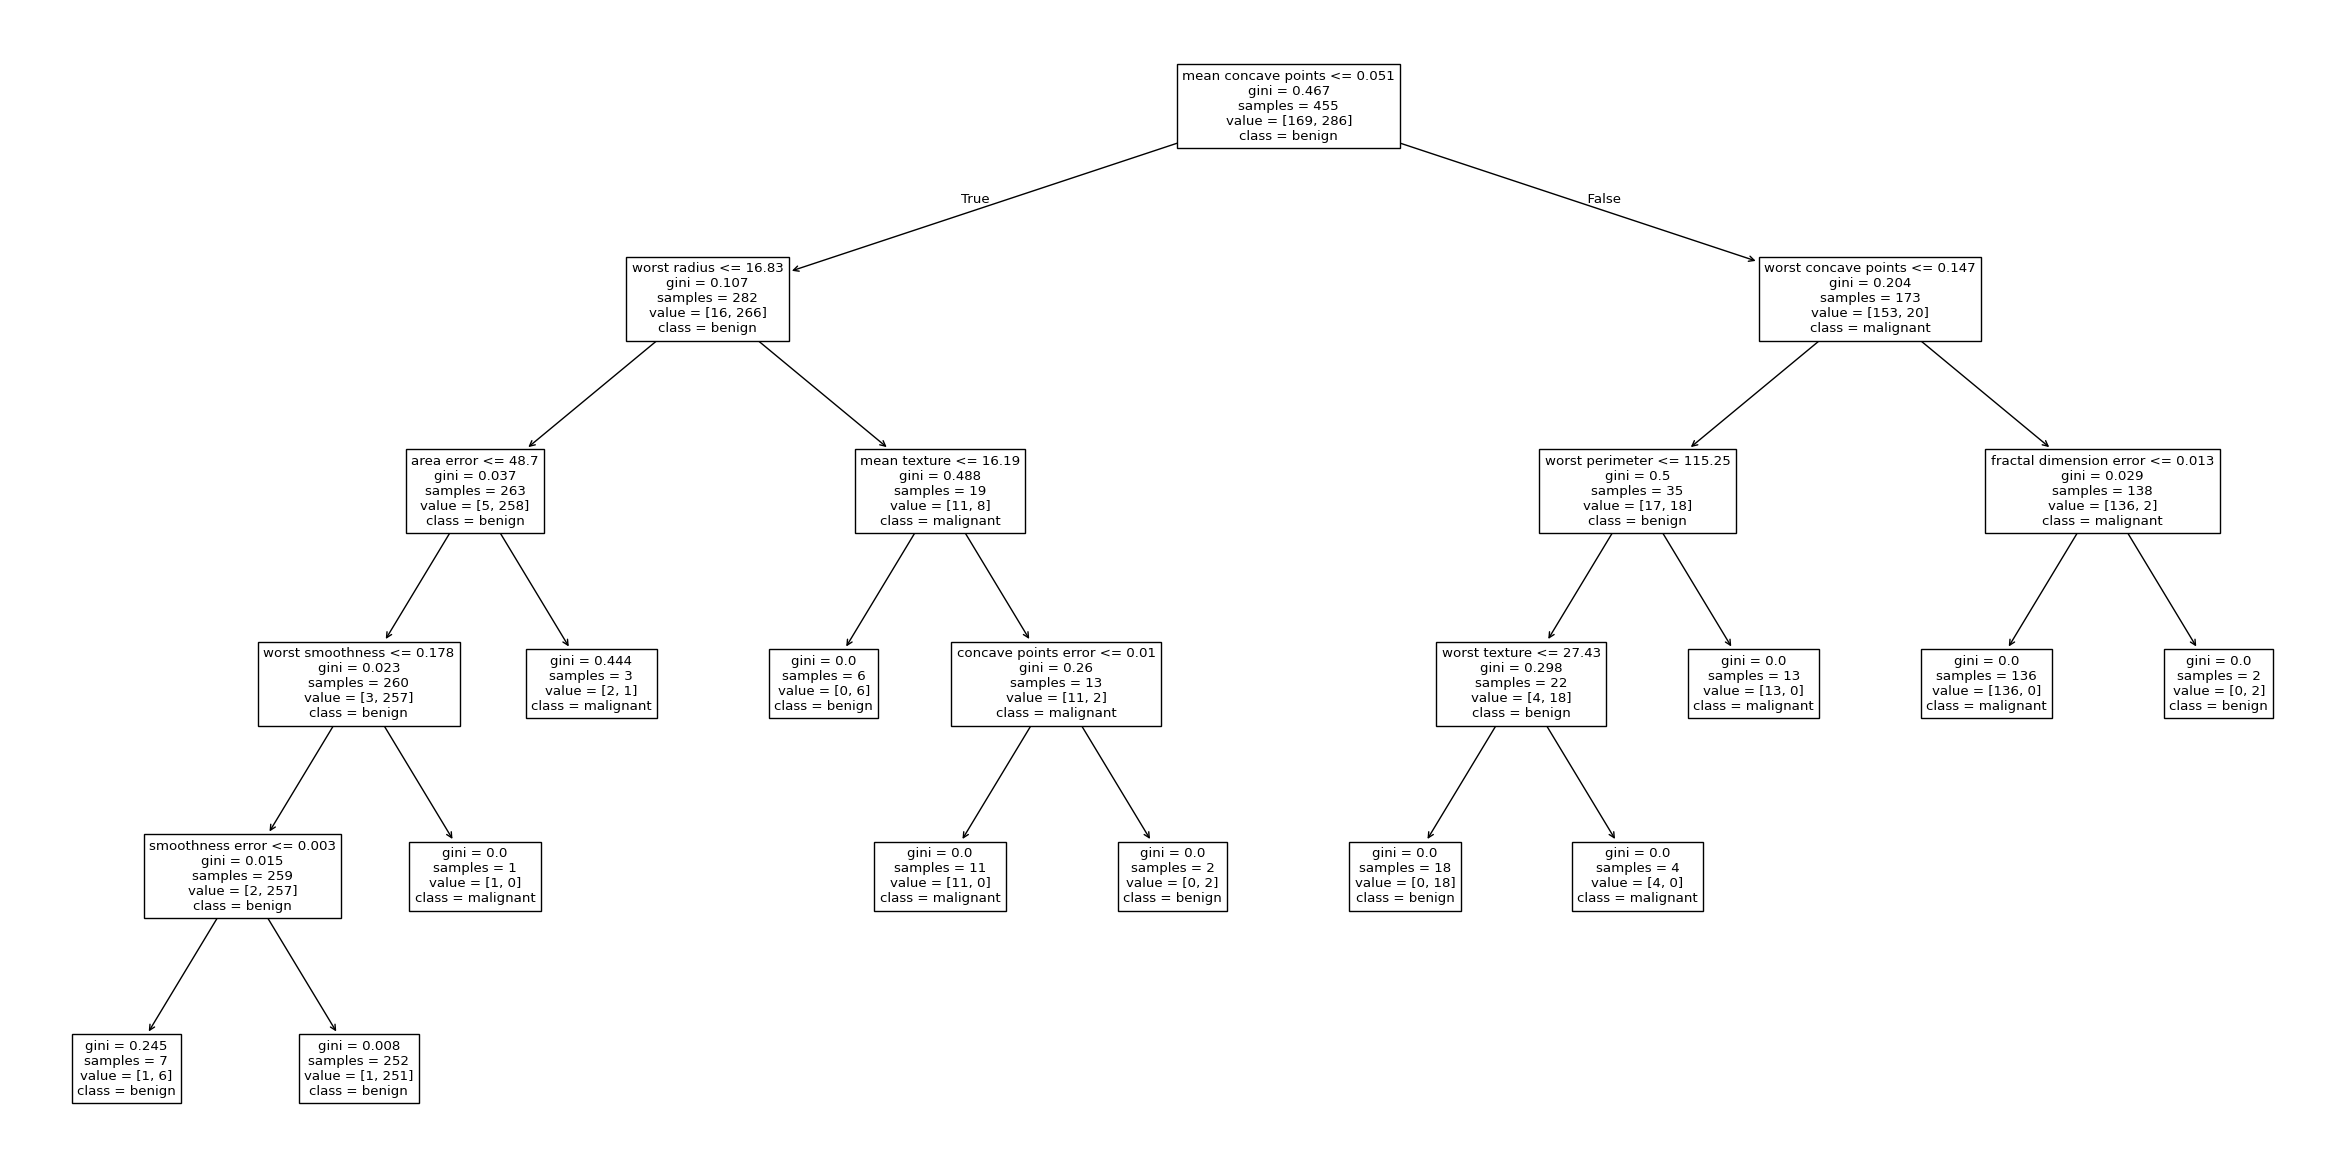

In [ ]:
# Visualize the Decision Tree
plt.figure(figsize=(30,15))
plot_tree(classifier,
          feature_names=dataset.feature_names,
          class_names=dataset.target_names)
plt.show()

In [ ]:
# Train random forest model
random_forest = RandomForestClassifier(n_estimators=200,
                                       max_depth=5,
                                       min_samples_split=5,
                                       random_state=40)
random_forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=5, n_estimators=200,
                       random_state=40)

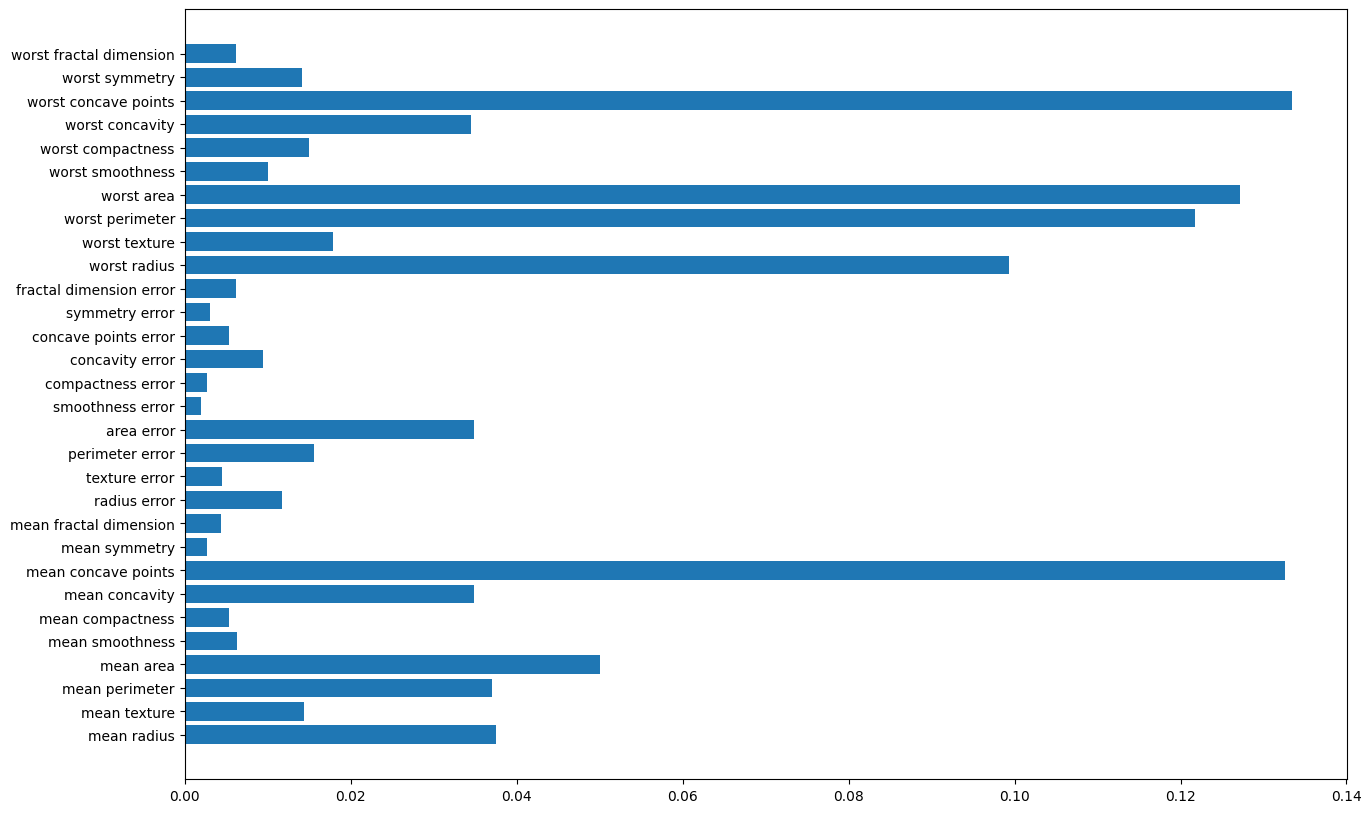

In [ ]:
# Extract feature importances
feature_importance = pd.DataFrame({
    'Feature': dataset.feature_names,
    'Importance': random_forest.feature_importances_
})
# Print feature importance
plt.figure(figsize=(15,10))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Build and train an AdaBoostClassifier on your training data.
weak_learner = DecisionTreeClassifier(max_depth=5)
ada_boost = AdaBoostClassifier(weak_learner)
ada_boost.fit(x_train, y_train)

# Evaluate models
models = [classifier, random_forest, ada_boost]
for model in models:
    prediction = model.predict(x_test)

    print("====================================================================")
    print(f"Model {model}")
    print("Accuracy:", accuracy_score(y_test, prediction))
    print("Confusion matrix:\n", confusion_matrix(y_test, prediction))
    print("Classification report:\n", classification_report(y_test, prediction))


Model DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=40)
Accuracy: 0.9385964912280702
Confusion matrix:
 [[39  4]
 [ 3 68]]
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Model RandomForestClassifier(max_depth=5, min_samples_split=5, n_estimators=200,
                       random_state=40)
Accuracy: 0.9649122807017544
Confusion matrix:
 [[40  3]
 [ 1 70]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg      